# Sentinel-1 SAR Temporal Analysis - Temporal evolution of **VV**, **VH** backscatter (dB) and **SAR false-color composites** (R=VV, G=VH, B=VV/VH).

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

In [8]:
ZARR_PATH = "/Users/ivanr/Developer/ai-vineyard-productivity/agrixel-fair-dockerV2/data/output/files/SENTINEL-1/L62196,L62198/cube.zarr"

ds = xr.open_zarr(ZARR_PATH, consolidated=False)
ds["variable"] = ds["variable"].astype("str")
n_times = ds.sizes["time"]
ncols = 4
nrows = int(np.ceil(n_times / ncols))

print(ds)
print(f"\nDates: {[str(t)[:10] for t in ds.time.values]}")

<xarray.Dataset> Size: 11MB
Dimensions:   (time: 12, variable: 2, y: 334, x: 331)
Coordinates:
  * time      (time) datetime64[ns] 96B 2021-02-20T17:55:09 ... 2021-09-30T17...
  * variable  (variable) <U2 16B 'VV' 'VH'
  * y         (y) float64 3kB 5.033e+06 5.033e+06 ... 5.03e+06 5.03e+06
  * x         (x) float64 3kB 3.196e+04 3.197e+04 ... 3.525e+04 3.526e+04
Data variables:
    data      (time, variable, y, x) float32 11MB ...
Attributes:
    crs:        EPSG:3857
    res_m:      10.0
    height:     334
    width:      331
    transform:  [10.0, 0.0, 31952.564242671506, 0.0, -10.0, 5033445.3646171605]
    variables:  ['VV', 'VH']
    time_iso:   ['2021-02-20T17:55:09Z', '2021-03-10T17:54:16Z', '2021-03-28T...

Dates: ['2021-02-20', '2021-03-10', '2021-03-28', '2021-04-21', '2021-05-09', '2021-05-27', '2021-06-20', '2021-07-08', '2021-07-26', '2021-08-19', '2021-09-06', '2021-09-30']


In [9]:
EPS = 1e-10

def dn_to_sigma0(dn):
    """Convert digital numbers to sigma0 linear: sigma0 = DN^2 / 1e9."""
    return dn.astype(float) ** 2 / 1e9

def to_db_filtered(sigma0, filter_size=3):
    """Convert sigma0 linear to dB with eps guard, then apply median filter."""
    db = 10 * np.log10(sigma0 + EPS)
    db = median_filter(db, size=filter_size)
    return db

def normalize_band(band, mask, pmin=2, pmax=98):
    """Percentile-stretch a band to [0, 1]."""
    if mask.sum() == 0:
        return np.zeros_like(band)
    vmin, vmax = np.percentile(band[mask], (pmin, pmax))
    out = np.clip(band, vmin, vmax)
    out = (out - vmin) / (vmax - vmin + EPS)
    out[~mask] = 0
    return out

## VV Backscatter (dB) — Temporal Evolution

/var/folders/px/2blwyyr1699bm6tby6n9xf440000gn/T/ipykernel_79618/4136870503.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


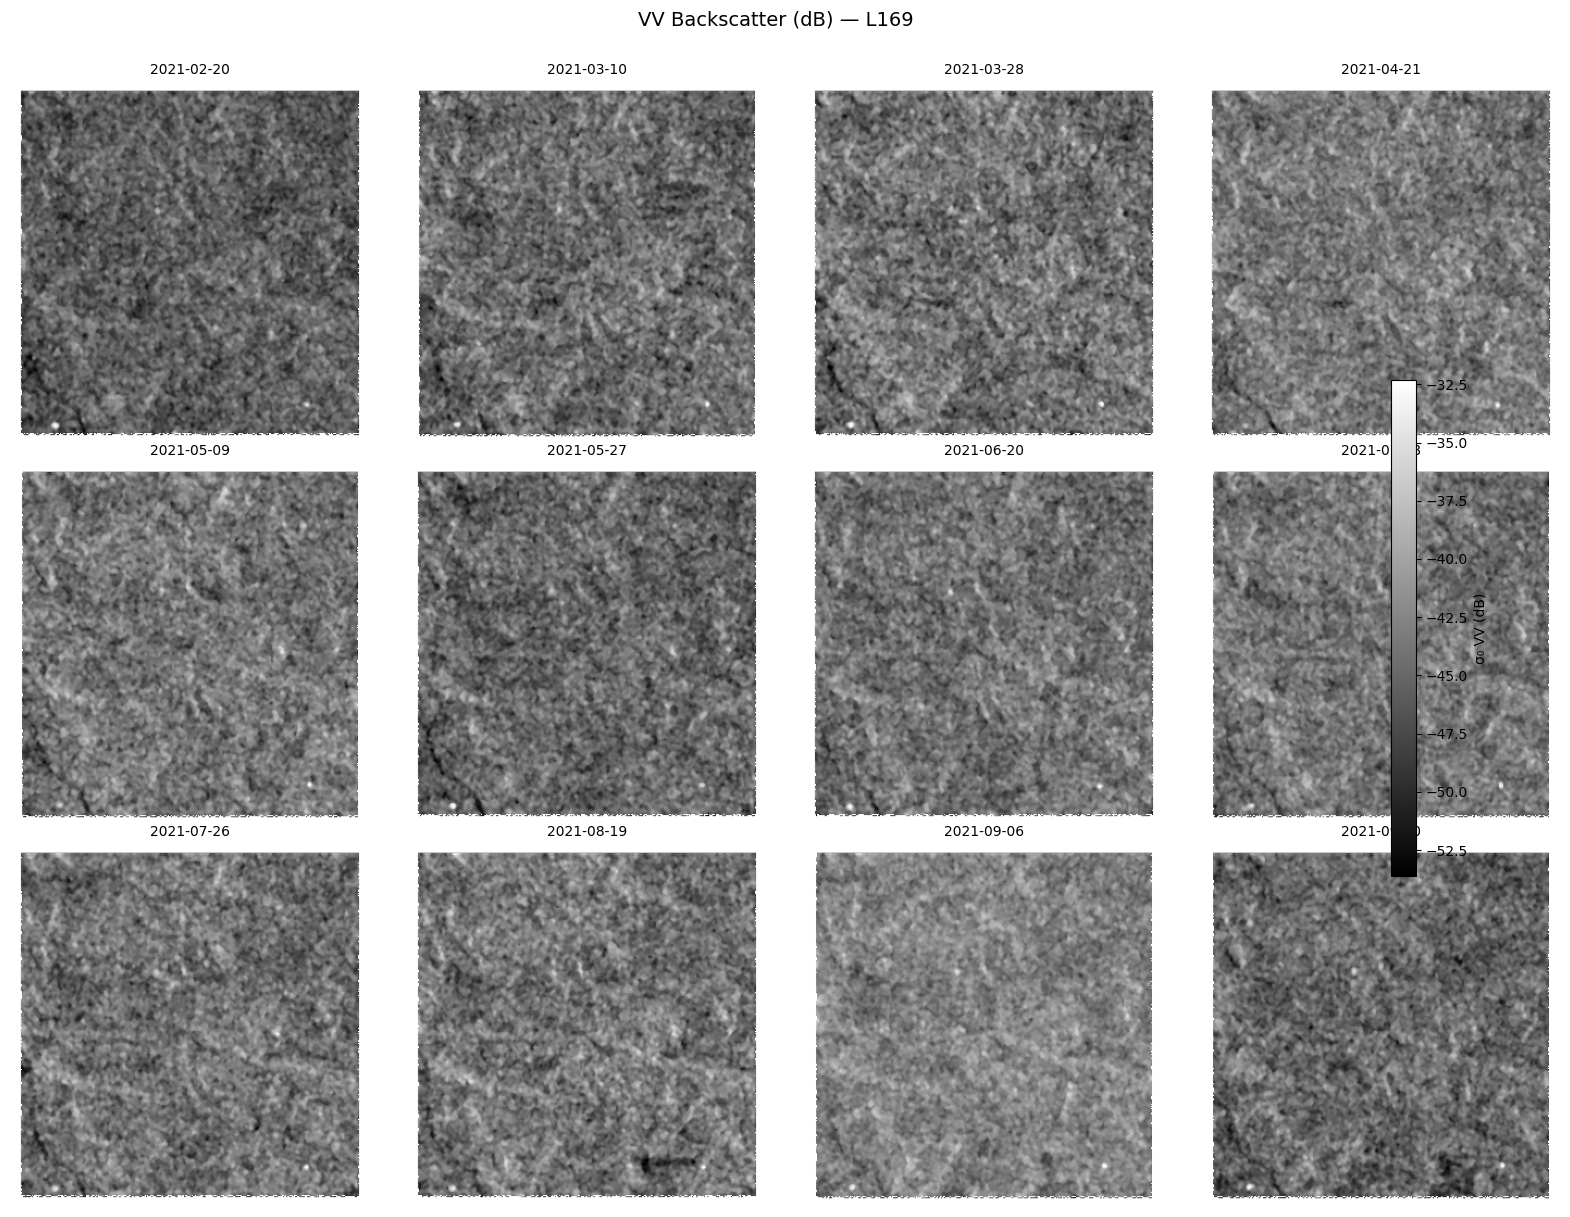

In [16]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes).flatten()

for i in range(n_times):
    vv = dn_to_sigma0(ds["data"].sel(variable="VV").isel(time=i).values)
    vv_db = to_db_filtered(vv)
    date_str = str(ds.time.values[i])[:10]

    im = axes[i].imshow(vv_db, cmap="gray", origin="upper")
    axes[i].set_title(date_str, fontsize=10)
    axes[i].axis("off")

for j in range(n_times, len(axes)):
    axes[j].axis("off")

fig.suptitle("VV Backscatter (dB) — L169", fontsize=14, y=1.01)
fig.colorbar(im, ax=axes, label="σ₀ VV (dB)", fraction=0.02, pad=0.04, shrink=0.6)
plt.tight_layout()
plt.show()

## VH Backscatter (dB) — Temporal Evolution

/var/folders/px/2blwyyr1699bm6tby6n9xf440000gn/T/ipykernel_79618/4125652121.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


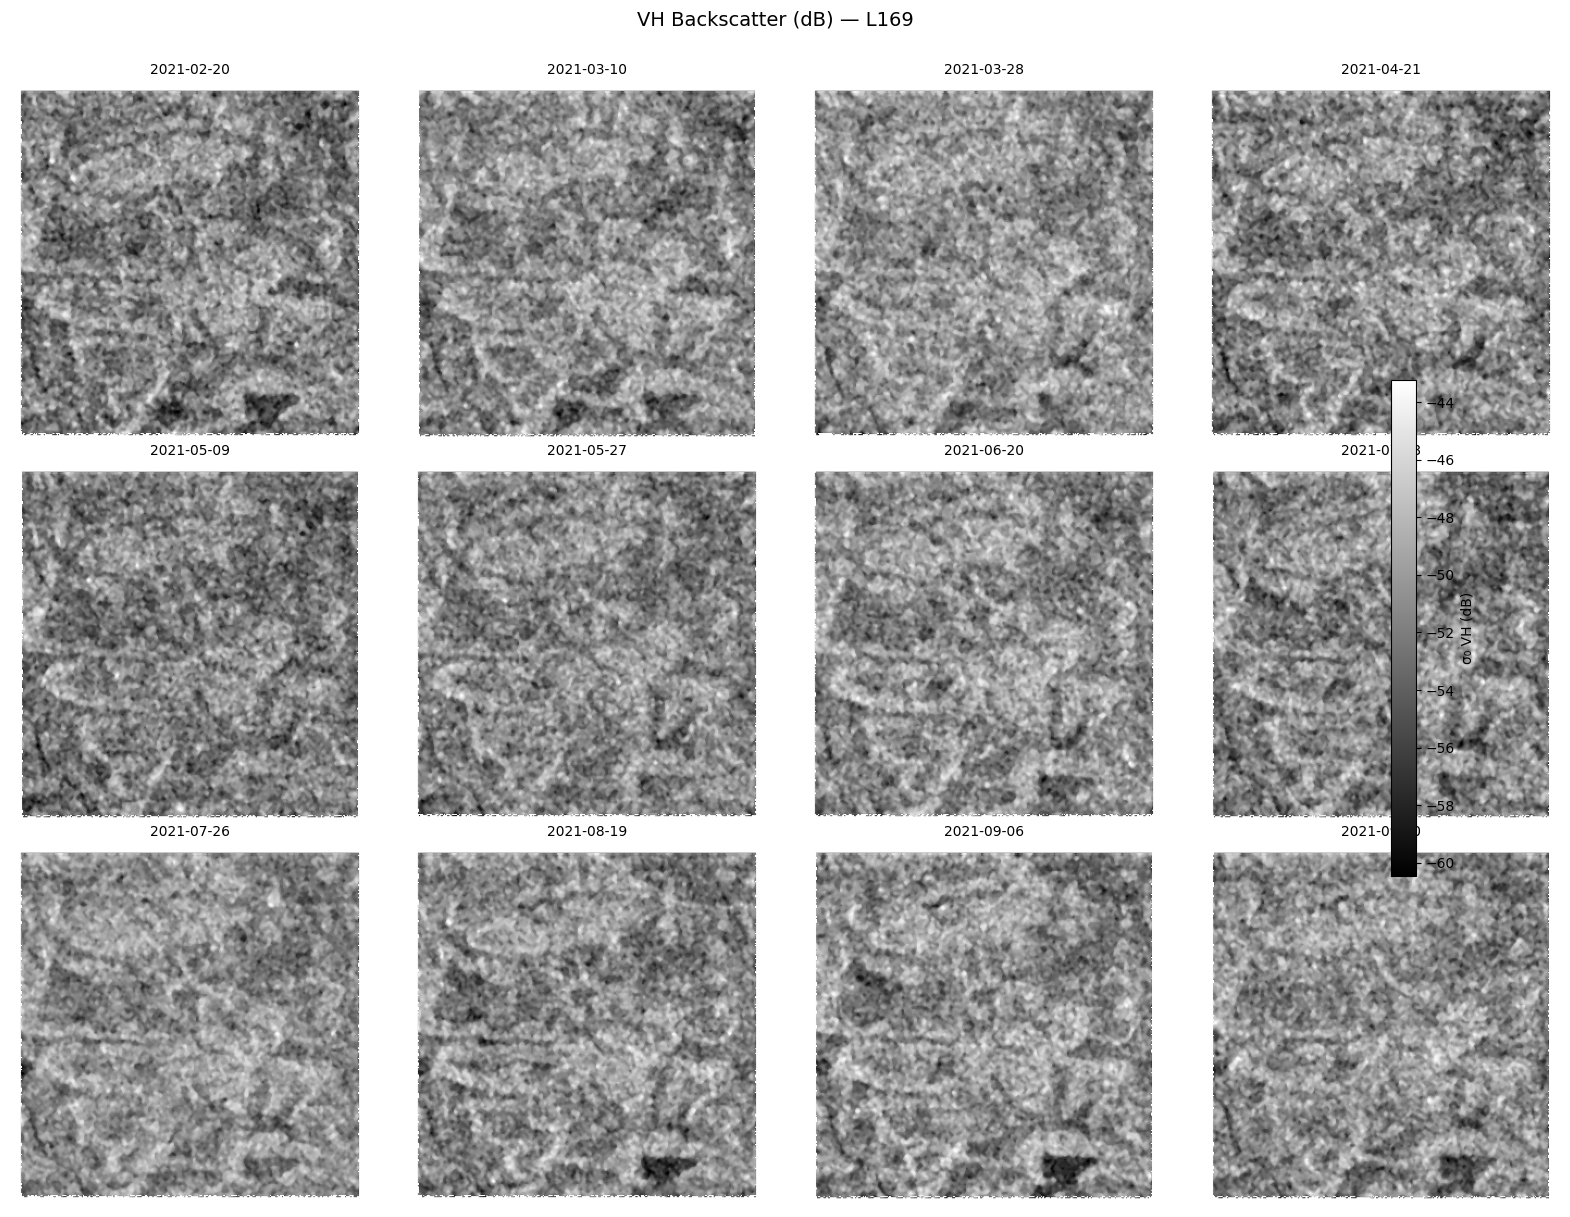

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes).flatten()

for i in range(n_times):
    vh = dn_to_sigma0(ds["data"].sel(variable="VH").isel(time=i).values)
    vh_db = to_db_filtered(vh)
    date_str = str(ds.time.values[i])[:10]

    im = axes[i].imshow(vh_db, cmap="grey", origin="upper")
    axes[i].set_title(date_str, fontsize=10)
    axes[i].axis("off")

for j in range(n_times, len(axes)):
    axes[j].axis("off")

fig.suptitle("VH Backscatter (dB) — L169", fontsize=14, y=1.01)
fig.colorbar(im, ax=axes, label="σ₀ VH (dB)", fraction=0.02, pad=0.04, shrink=0.6)
plt.tight_layout()
plt.show()

## SAR False Color Composite (R=VV, G=VH, B=VV/VH) — Temporal Evolution

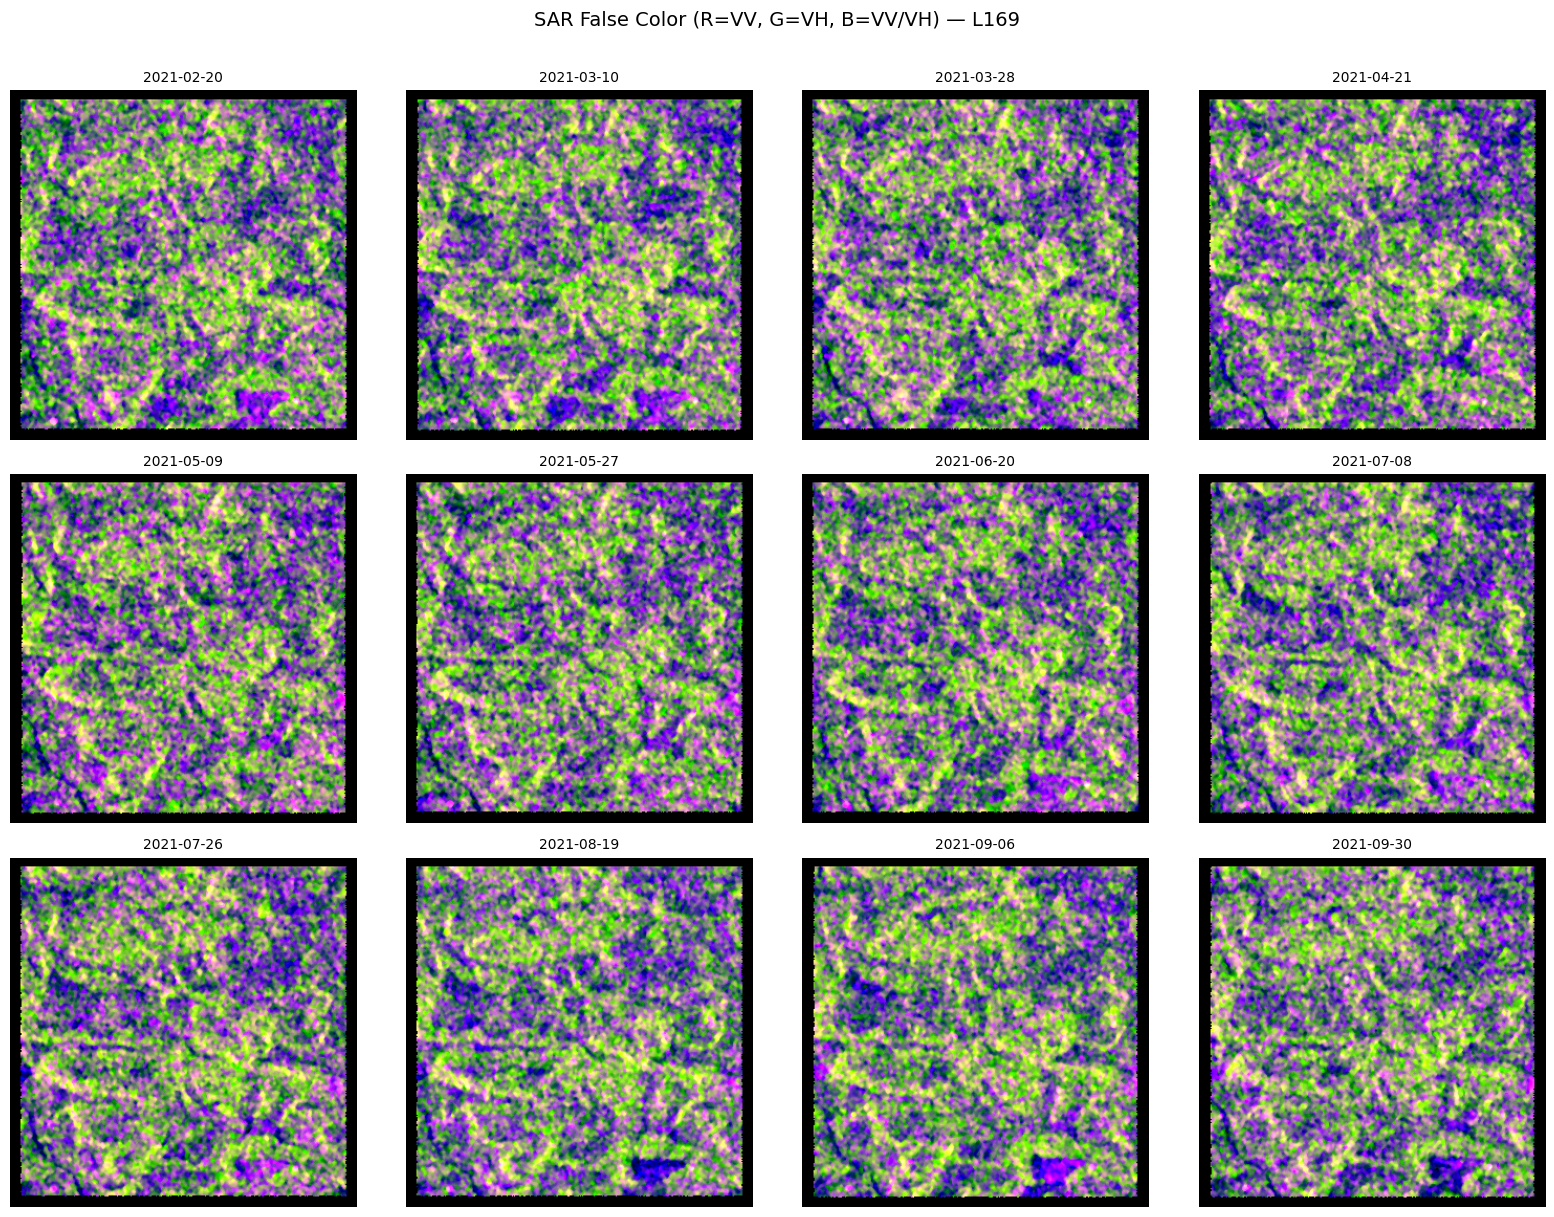

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes).flatten()

for i in range(n_times):
    vv = dn_to_sigma0(ds["data"].sel(variable="VV").isel(time=i).values)
    vh = dn_to_sigma0(ds["data"].sel(variable="VH").isel(time=i).values)

    vv_db = to_db_filtered(vv)
    vh_db = to_db_filtered(vh)

    # Mask nodata (original zero-backscatter pixels → ~-100 dB)
    valid = (vv > 0) & (vh > 0) & np.isfinite(vv_db) & np.isfinite(vh_db)

    ratio_db = vv_db - vh_db  # VV/VH in dB

    vv_n = normalize_band(vv_db, valid)
    vh_n = normalize_band(vh_db, valid)
    ratio_n = normalize_band(ratio_db, valid)

    rgb = np.stack([vv_n, vh_n, ratio_n], axis=-1)
    date_str = str(ds.time.values[i])[:10]

    axes[i].imshow(rgb, origin="upper")
    axes[i].set_title(date_str, fontsize=10)
    axes[i].axis("off")

for j in range(n_times, len(axes)):
    axes[j].axis("off")

fig.suptitle("SAR False Color (R=VV, G=VH, B=VV/VH) — L169", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()